<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 40px; margin: -10px -10px 20px -10px; border-radius: 0 0 15px 15px;">
<h1 style="margin: 0; font-size: 2.5em;">Josephson Junctions</h1>
<p style="margin: 10px 0 0 0; font-size: 1.2em; opacity: 0.9;">Week 1, Session 3 — SCE Futures</p>
</div>

## Contents

- [Learning Objectives](#learning-objectives)

1. [The Josephson Effect](#1-josephson-effect)
2. [I-V Characteristics](#2-iv-characteristics)
3. [RCSJ Model](#3-rcsj-model)
4. [Junction Types](#4-junction-types)
5. [Key Parameters](#5-key-parameters)
6. [Fabrication Overview](#6-fabrication)

---
<a id="learning-objectives"></a>
## Learning Objectives

By the end of this session, you will be able to:

- Explain the DC and AC Josephson effects and their physical origins
- Interpret Josephson junction I-V characteristics and understand hysteresis
- Apply the RCSJ model to analyze junction dynamics
- Compare different junction types (SIS, SNS, SFS) and their applications
- Calculate key junction parameters (I_c, R_n, I_cR_n product, beta_c)
- Describe the basic fabrication process for Nb-based tunnel junctions

---

In [1]:
# Setup: Import libraries for visualizations and calculations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, Rectangle, FancyArrowPatch
from matplotlib.lines import Line2D
import numpy as np
from scipy.integrate import odeint, solve_ivp
from scipy.signal import find_peaks

# Color scheme (consistent with course)
COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'superconducting': '#00BCD4',
    'normal': '#9E9E9E',
    'purple': '#9C27B0',
    'teal': '#009688'
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Physical constants
h = 6.62607015e-34      # Planck constant (J·s)
hbar = h / (2 * np.pi)  # Reduced Planck constant
e = 1.602176634e-19     # Elementary charge (C)
k_B = 1.380649e-23      # Boltzmann constant (J/K)
Phi_0 = h / (2 * e)     # Flux quantum (Wb)

print("Setup complete.")
print(f"Flux quantum: Phi_0 = {Phi_0:.6e} Wb = {Phi_0*1e15:.4f} fWb")

Setup complete.
Flux quantum: Phi_0 = 2.067834e-15 Wb = 2.0678 fWb


---
<a id="1-josephson-effect"></a>
# 1. The Josephson Effect
---

In 1962, Brian Josephson (then a 22-year-old graduate student at Cambridge) made a remarkable prediction: **Cooper pairs can tunnel through a thin insulating barrier between two superconductors**, producing macroscopic quantum effects. This prediction earned him the Nobel Prize in Physics in 1973.

### The Physical Picture

Consider two superconductors separated by a thin barrier (typically 1-2 nm of oxide):

- Each superconductor has a macroscopic wave function: $\Psi_1 = |\Psi_1|e^{i\phi_1}$ and $\Psi_2 = |\Psi_2|e^{i\phi_2}$
- The wave functions overlap through the thin barrier
- Cooper pairs can tunnel coherently from one side to the other
- The supercurrent depends on the **phase difference** $\varphi = \phi_1 - \phi_2$

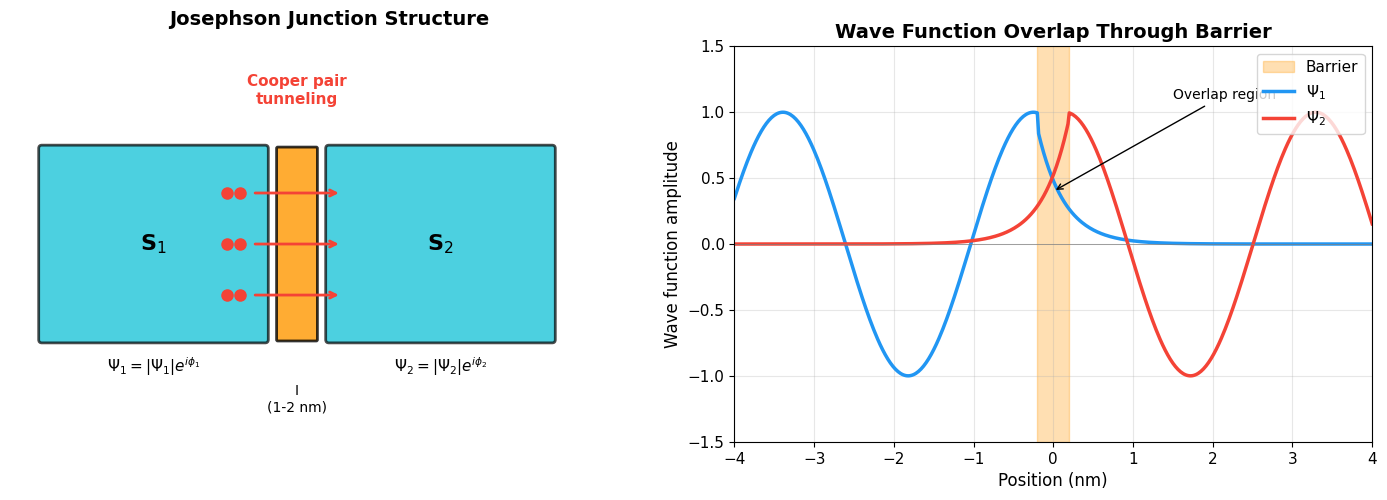

In [2]:
# Visualize: Josephson junction structure and Cooper pair tunneling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Junction structure
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Josephson Junction Structure', fontsize=14, fontweight='bold', pad=20)

# Draw superconductors
sc1 = FancyBboxPatch((0.5, 1.5), 3.5, 3, boxstyle="round,pad=0.05", 
                      facecolor=COLORS['superconducting'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.add_patch(sc1)
ax1.text(2.25, 3, 'S$_1$', fontsize=16, ha='center', va='center', fontweight='bold')
ax1.text(2.25, 1, r'$\Psi_1 = |\Psi_1|e^{i\phi_1}$', fontsize=11, ha='center')

# Insulating barrier
barrier = FancyBboxPatch((4.2, 1.5), 0.6, 3, boxstyle="round,pad=0.02",
                          facecolor=COLORS['secondary'], alpha=0.8, edgecolor='black', linewidth=2)
ax1.add_patch(barrier)
ax1.text(4.5, 0.8, 'I\n(1-2 nm)', fontsize=10, ha='center', va='top')

# Second superconductor
sc2 = FancyBboxPatch((5, 1.5), 3.5, 3, boxstyle="round,pad=0.05",
                      facecolor=COLORS['superconducting'], alpha=0.7, edgecolor='black', linewidth=2)
ax1.add_patch(sc2)
ax1.text(6.75, 3, 'S$_2$', fontsize=16, ha='center', va='center', fontweight='bold')
ax1.text(6.75, 1, r'$\Psi_2 = |\Psi_2|e^{i\phi_2}$', fontsize=11, ha='center')

# Cooper pairs tunneling
for y in [2.2, 3, 3.8]:
    ax1.annotate('', xy=(5.2, y), xytext=(3.8, y),
                arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
    ax1.plot(3.6, y, 'o', color=COLORS['danger'], markersize=8)
    ax1.plot(3.4, y, 'o', color=COLORS['danger'], markersize=8)

ax1.text(4.5, 5.2, 'Cooper pair\ntunneling', fontsize=11, ha='center', 
         color=COLORS['danger'], fontweight='bold')

# Right: Wave function overlap
ax2.set_title('Wave Function Overlap Through Barrier', fontsize=14, fontweight='bold')
x = np.linspace(-4, 4, 500)

# Wave functions decaying into barrier
psi1 = np.where(x < -0.2, np.cos(2*x + 0.5), np.exp(-3*(x + 0.2)) * np.cos(0.5))
psi2 = np.where(x > 0.2, np.cos(2*x - 0.3), np.exp(3*(x - 0.2)) * np.cos(-0.3))

ax2.fill_between([-0.2, 0.2], -1.5, 1.5, color=COLORS['secondary'], alpha=0.3, label='Barrier')
ax2.plot(x, psi1, color=COLORS['primary'], linewidth=2.5, label=r'$\Psi_1$')
ax2.plot(x, psi2, color=COLORS['danger'], linewidth=2.5, label=r'$\Psi_2$')

ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Position (nm)', fontsize=12)
ax2.set_ylabel('Wave function amplitude', fontsize=12)
ax2.set_xlim(-4, 4)
ax2.set_ylim(-1.5, 1.5)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Annotations
ax2.annotate('Overlap region', xy=(0, 0.4), xytext=(1.5, 1.1),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.show()

### DC Josephson Effect

The **DC Josephson effect** describes the supercurrent that flows at zero voltage:

$$\boxed{I = I_c \sin(\varphi)}$$

where:
- $I$ is the supercurrent through the junction
- $I_c$ is the **critical current** (maximum supercurrent)
- $\varphi = \phi_1 - \phi_2$ is the phase difference across the junction

**Key implications:**
- For $I < I_c$: current flows with **zero voltage** (supercurrent)
- The junction "chooses" the phase $\varphi = \arcsin(I/I_c)$ to carry the applied current
- At $I = I_c$: the phase reaches $\pi/2$ and cannot increase further
- For $I > I_c$: the junction switches to a voltage state

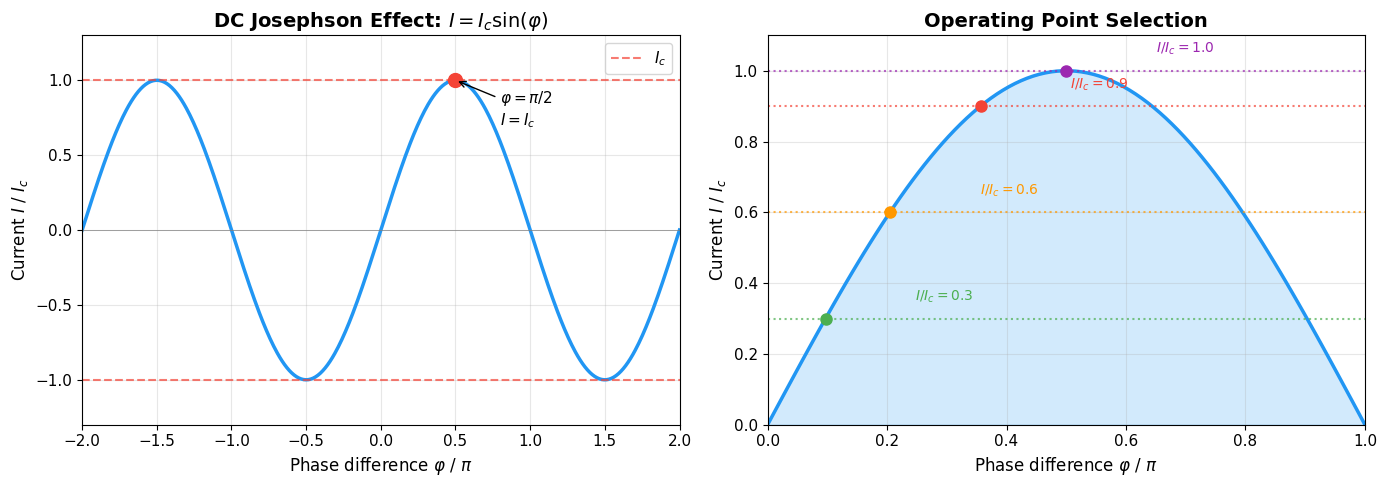

Key insight: The junction automatically adjusts its phase to carry the applied current.
For I/Ic = 0.5, the phase is arcsin(0.5) = pi/6 = 30 degrees


In [3]:
# Visualize: The DC Josephson relation I = Ic sin(phi)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Current vs phase
phi = np.linspace(-2*np.pi, 2*np.pi, 500)
I_normalized = np.sin(phi)

ax1.plot(phi/np.pi, I_normalized, color=COLORS['primary'], linewidth=2.5)
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.axhline(1, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7, label='$I_c$')
ax1.axhline(-1, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7)

# Mark key points
ax1.plot([0.5], [1], 'o', color=COLORS['danger'], markersize=10)
ax1.annotate('$\\varphi = \\pi/2$\n$I = I_c$', xy=(0.5, 1), xytext=(0.8, 0.7),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

ax1.set_xlabel('Phase difference $\\varphi$ / $\\pi$', fontsize=12)
ax1.set_ylabel('Current $I$ / $I_c$', fontsize=12)
ax1.set_title('DC Josephson Effect: $I = I_c \\sin(\\varphi)$', fontsize=14, fontweight='bold')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1.3, 1.3)
ax1.set_xticks([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Operating point selection
phi_op = np.linspace(0, np.pi, 100)
I_op = np.sin(phi_op)

ax2.plot(phi_op/np.pi, I_op, color=COLORS['primary'], linewidth=2.5)
ax2.fill_between(phi_op/np.pi, 0, I_op, alpha=0.2, color=COLORS['primary'])

# Show different operating currents
currents = [0.3, 0.6, 0.9, 1.0]
colors_list = [COLORS['success'], COLORS['secondary'], COLORS['danger'], COLORS['purple']]

for I_target, color in zip(currents, colors_list):
    if I_target <= 1:
        phi_target = np.arcsin(I_target)
        ax2.axhline(I_target, color=color, linestyle=':', linewidth=1.5, alpha=0.7)
        ax2.plot([phi_target/np.pi], [I_target], 'o', color=color, markersize=8)
        ax2.annotate(f'$I/I_c = {I_target}$', xy=(phi_target/np.pi, I_target), 
                    xytext=(phi_target/np.pi + 0.15, I_target + 0.05), fontsize=10, color=color)

ax2.set_xlabel('Phase difference $\\varphi$ / $\\pi$', fontsize=12)
ax2.set_ylabel('Current $I$ / $I_c$', fontsize=12)
ax2.set_title('Operating Point Selection', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: The junction automatically adjusts its phase to carry the applied current.")
print("For I/Ic = 0.5, the phase is arcsin(0.5) = pi/6 = 30 degrees")

### AC Josephson Effect

When a voltage $V$ is applied across the junction, the phase evolves in time:

$$\boxed{V = \frac{\Phi_0}{2\pi}\frac{d\varphi}{dt}}$$

or equivalently:

$$\frac{d\varphi}{dt} = \frac{2\pi V}{\Phi_0} = \frac{2eV}{\hbar}$$

For a constant voltage $V$, the phase increases linearly: $\varphi(t) = \varphi_0 + (2\pi V/\Phi_0)t$

This produces an **oscillating supercurrent** at the **Josephson frequency**:

$$\boxed{f_J = \frac{V}{\Phi_0} = \frac{2eV}{h}}$$

**Josephson constant:**
$$K_J = \frac{2e}{h} = 483.5979 \text{ GHz/mV}$$

This exact relationship between voltage and frequency is the basis for the **Josephson voltage standard**.

In [4]:
# Calculate Josephson frequency for various voltages
K_J = 2 * e / h  # Josephson constant (Hz/V)

print("AC Josephson Effect: Frequency-Voltage Relation")
print("=" * 50)
print(f"Josephson constant: K_J = 2e/h = {K_J/1e9:.4f} GHz/mV")
print(f"                         = {K_J/1e12:.6f} THz/V")
print()
print("Josephson frequencies for typical voltages:")
print("-" * 50)

voltages_uV = [1, 10, 100, 1000, 2000, 3000]  # microvolts
for V_uV in voltages_uV:
    V = V_uV * 1e-6  # Convert to volts
    f = K_J * V      # Frequency in Hz
    if f < 1e9:
        print(f"  V = {V_uV:5d} uV  ->  f = {f/1e6:8.2f} MHz")
    elif f < 1e12:
        print(f"  V = {V_uV:5d} uV  ->  f = {f/1e9:8.2f} GHz")
    else:
        print(f"  V = {V_uV:5d} uV  ->  f = {f/1e12:8.3f} THz")

print()
print("Note: At the Nb gap voltage (2.8 mV), f = 1.35 THz")
print("This is why Josephson junctions are inherently high-frequency devices!")

AC Josephson Effect: Frequency-Voltage Relation
Josephson constant: K_J = 2e/h = 483597.8484 GHz/mV
                         = 483.597848 THz/V

Josephson frequencies for typical voltages:
--------------------------------------------------
  V =     1 uV  ->  f =   483.60 MHz
  V =    10 uV  ->  f =     4.84 GHz
  V =   100 uV  ->  f =    48.36 GHz
  V =  1000 uV  ->  f =   483.60 GHz
  V =  2000 uV  ->  f =   967.20 GHz
  V =  3000 uV  ->  f =    1.451 THz

Note: At the Nb gap voltage (2.8 mV), f = 1.35 THz
This is why Josephson junctions are inherently high-frequency devices!


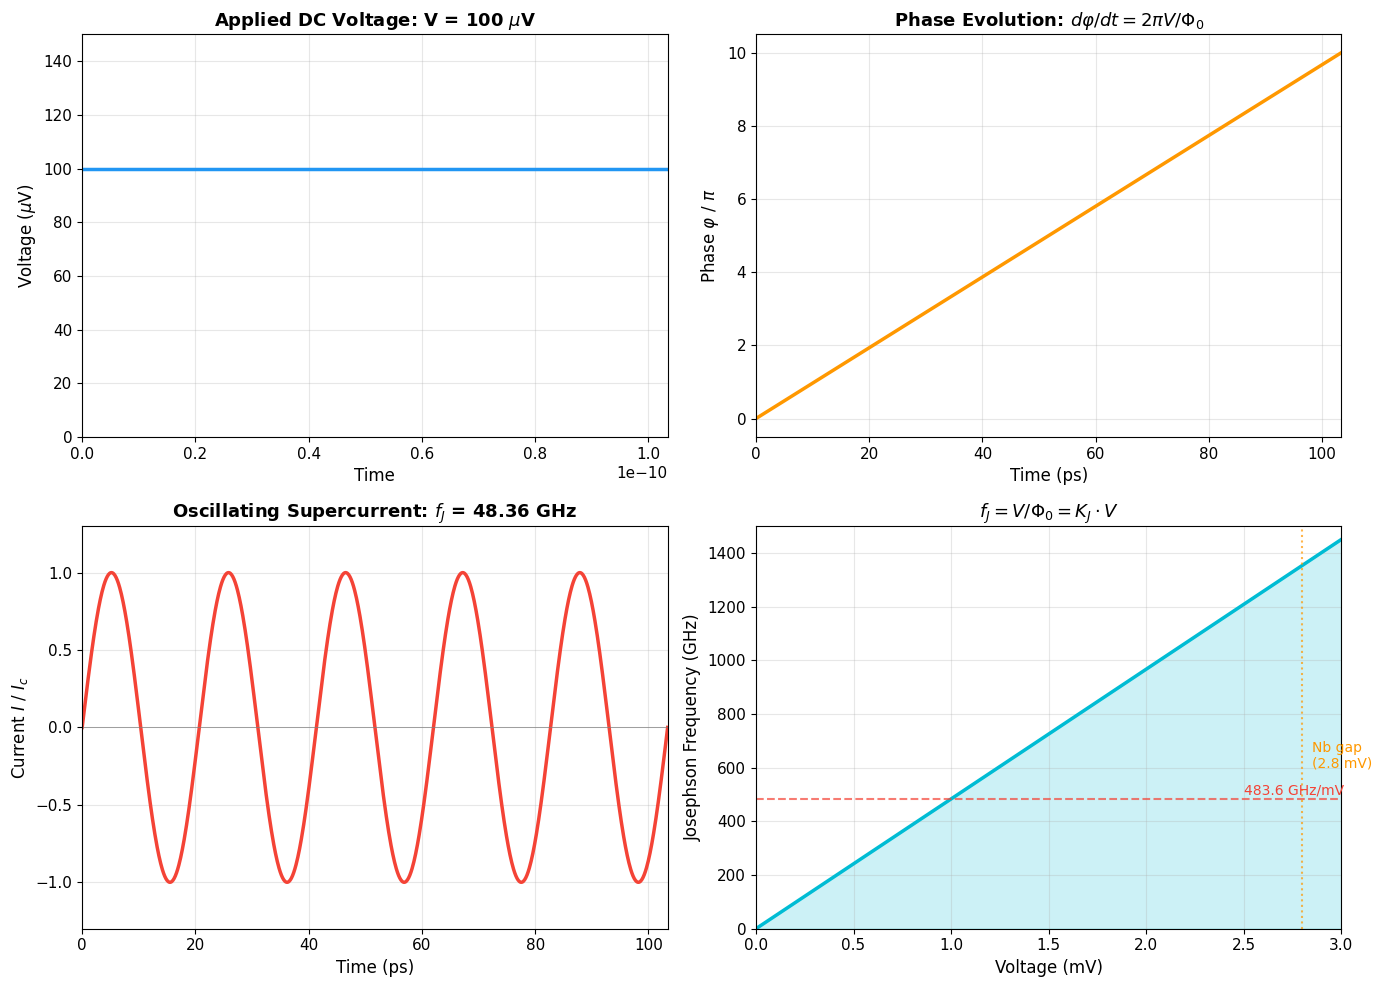

In [5]:
# Visualize: AC Josephson effect - oscillating current at constant voltage
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameters
V_dc = 0.1e-3  # 100 uV DC voltage
f_J = K_J * V_dc  # Josephson frequency
T_J = 1 / f_J     # Josephson period

t = np.linspace(0, 5*T_J, 1000)
phi = 2 * np.pi * f_J * t
I = np.sin(phi)

# Top left: Voltage (constant)
ax = axes[0, 0]
ax.axhline(V_dc * 1e6, color=COLORS['primary'], linewidth=2.5)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Voltage ($\\mu$V)', fontsize=12)
ax.set_title(f'Applied DC Voltage: V = {V_dc*1e6:.0f} $\\mu$V', fontsize=13, fontweight='bold')
ax.set_xlim(0, t[-1])
ax.set_ylim(0, 150)
ax.grid(True, alpha=0.3)

# Top right: Phase (linear increase)
ax = axes[0, 1]
ax.plot(t * 1e12, phi / np.pi, color=COLORS['secondary'], linewidth=2.5)
ax.set_xlabel('Time (ps)', fontsize=12)
ax.set_ylabel('Phase $\\varphi$ / $\\pi$', fontsize=12)
ax.set_title('Phase Evolution: $d\\varphi/dt = 2\\pi V/\\Phi_0$', fontsize=13, fontweight='bold')
ax.set_xlim(0, t[-1] * 1e12)
ax.grid(True, alpha=0.3)

# Bottom left: Current (oscillating)
ax = axes[1, 0]
ax.plot(t * 1e12, I, color=COLORS['danger'], linewidth=2.5)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Time (ps)', fontsize=12)
ax.set_ylabel('Current $I$ / $I_c$', fontsize=12)
ax.set_title(f'Oscillating Supercurrent: $f_J$ = {f_J/1e9:.2f} GHz', fontsize=13, fontweight='bold')
ax.set_xlim(0, t[-1] * 1e12)
ax.set_ylim(-1.3, 1.3)
ax.grid(True, alpha=0.3)

# Bottom right: Frequency vs Voltage
ax = axes[1, 1]
V_range = np.linspace(0, 3, 100)  # mV
f_range = K_J * V_range * 1e-3 / 1e9  # GHz

ax.plot(V_range, f_range, color=COLORS['superconducting'], linewidth=2.5)
ax.fill_between(V_range, 0, f_range, alpha=0.2, color=COLORS['superconducting'])

# Mark typical operating points
ax.axhline(483.6, color=COLORS['danger'], linestyle='--', alpha=0.7)
ax.text(2.5, 500, '483.6 GHz/mV', fontsize=10, color=COLORS['danger'])

# Mark Nb gap voltage
ax.axvline(2.8, color=COLORS['secondary'], linestyle=':', alpha=0.7)
ax.text(2.85, 600, 'Nb gap\n(2.8 mV)', fontsize=10, color=COLORS['secondary'])

ax.set_xlabel('Voltage (mV)', fontsize=12)
ax.set_ylabel('Josephson Frequency (GHz)', fontsize=12)
ax.set_title('$f_J = V/\\Phi_0 = K_J \\cdot V$', fontsize=13, fontweight='bold')
ax.set_xlim(0, 3)
ax.set_ylim(0, 1500)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary: The Josephson Equations

| Effect | Equation | Physical Meaning |
|--------|----------|------------------|
| **DC Josephson** | $I = I_c \sin(\varphi)$ | Supercurrent at zero voltage |
| **AC Josephson** | $V = (\Phi_0/2\pi)(d\varphi/dt)$ | Phase evolution with voltage |
| **Josephson frequency** | $f_J = V/\Phi_0 = 483.6$ GHz/mV | Oscillation frequency |

These two equations, combined with circuit constraints, determine all Josephson junction behavior.

---
<a id="2-iv-characteristics"></a>
# 2. I-V Characteristics
---

The current-voltage (I-V) characteristic reveals the essential behavior of a Josephson junction. Understanding I-V curves is critical for circuit design.

### Zero-Voltage State (I < I_c)

For currents below the critical current:
- The junction carries supercurrent with **exactly zero voltage**
- Phase adjusts: $\varphi = \arcsin(I/I_c)$
- No power dissipation: $P = IV = 0$

### Switching at I_c

When current exceeds I_c:
- Phase can no longer stay constant
- Junction switches to voltage state
- In **underdamped** junctions: abrupt jump to gap voltage
- In **overdamped** junctions: gradual transition

### The Subgap Region and Gap Voltage

In SIS tunnel junctions:
- **Subgap region**: Very low resistance (quasiparticle tunneling suppressed)
- **Gap voltage**: $V_g = 2\Delta/e \approx 2.8$ mV for Nb
- Above $V_g$: Normal resistance behavior (quasiparticle current dominates)

/var/folders/vm/wfyvlqcx1nbcc7l_yn0sgjtm0000gn/T/ipykernel_6229/1273996975.py:49: RuntimeWarning: invalid value encountered in sqrt
  V_rsj = np.where(I_range < I_c, 0, R_n * np.sqrt(I_range**2 - I_c**2))


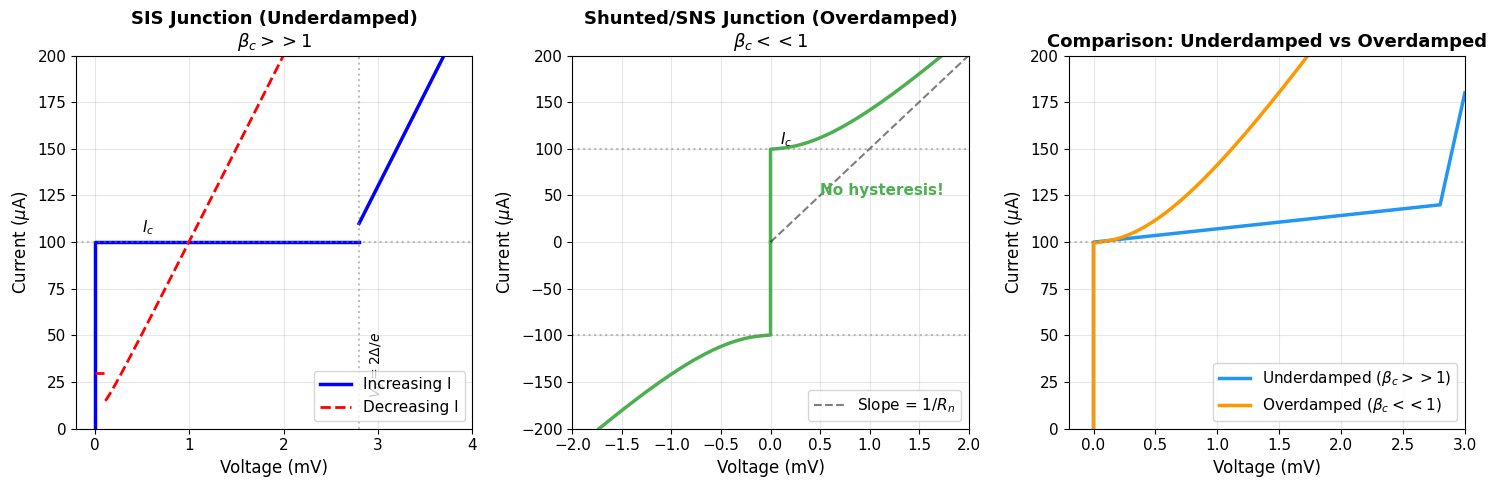

In [6]:
# Visualize: I-V characteristics for different junction types
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Common parameters
I_c = 100e-6  # 100 uA critical current
R_n = 10      # 10 ohm normal resistance
V_g = 2.8e-3  # Gap voltage for Nb (V)

# Left: Ideal SIS junction (hysteretic/underdamped)
ax = axes[0]
ax.set_title('SIS Junction (Underdamped)\n$\\beta_c >> 1$', fontsize=13, fontweight='bold')

# Increasing current branch
I_up = np.array([0, I_c, I_c])
V_up = np.array([0, 0, V_g])
ax.plot(V_up * 1e3, I_up * 1e6, 'b-', linewidth=2.5, label='Increasing I')

# Above gap
V_high = np.linspace(V_g, 4e-3, 50)
I_high = I_c + (V_high - V_g) / R_n + I_c * 0.1  # Simplified
ax.plot(V_high * 1e3, I_high * 1e6, 'b-', linewidth=2.5)

# Decreasing current branch (hysteresis)
I_r = 0.3 * I_c  # Retrapping current
V_down = np.linspace(V_g, 0.1e-3, 50)
I_down = np.sqrt((V_down / R_n)**2 + I_c**2 * 0.01)  # Simplified subgap
ax.plot(V_down * 1e3, I_down * 1e6, 'r--', linewidth=2, label='Decreasing I')
ax.plot([0.1e-3 * 1e3, 0], [I_r * 1e6, I_r * 1e6], 'r--', linewidth=2)

# Mark key points
ax.axhline(I_c * 1e6, color='gray', linestyle=':', alpha=0.5)
ax.axvline(V_g * 1e3, color='gray', linestyle=':', alpha=0.5)
ax.text(0.5, I_c * 1e6 + 5, '$I_c$', fontsize=11)
ax.text(V_g * 1e3 + 0.1, 20, '$V_g = 2\\Delta/e$', fontsize=10, rotation=90)

ax.set_xlabel('Voltage (mV)', fontsize=12)
ax.set_ylabel('Current ($\\mu$A)', fontsize=12)
ax.set_xlim(-0.2, 4)
ax.set_ylim(0, 200)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Middle: Overdamped junction (non-hysteretic)
ax = axes[1]
ax.set_title('Shunted/SNS Junction (Overdamped)\n$\\beta_c << 1$', fontsize=13, fontweight='bold')

# RSJ model: V = R * sqrt(I^2 - Ic^2) for I > Ic
I_range = np.linspace(0, 2 * I_c, 200)
V_rsj = np.where(I_range < I_c, 0, R_n * np.sqrt(I_range**2 - I_c**2))

ax.plot(V_rsj * 1e3, I_range * 1e6, color=COLORS['success'], linewidth=2.5)
ax.plot(-V_rsj * 1e3, -I_range * 1e6, color=COLORS['success'], linewidth=2.5)

# Asymptotic resistance line
V_asym = np.linspace(0, 2e-3, 50)
I_asym = V_asym / R_n
ax.plot(V_asym * 1e3, I_asym * 1e6, 'k--', alpha=0.5, label=f'Slope = 1/$R_n$')

ax.axhline(I_c * 1e6, color='gray', linestyle=':', alpha=0.5)
ax.axhline(-I_c * 1e6, color='gray', linestyle=':', alpha=0.5)
ax.text(0.1, I_c * 1e6 + 5, '$I_c$', fontsize=11)

ax.set_xlabel('Voltage (mV)', fontsize=12)
ax.set_ylabel('Current ($\\mu$A)', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-200, 200)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.annotate('No hysteresis!', xy=(0.5, 50), fontsize=11, color=COLORS['success'], fontweight='bold')

# Right: I-V comparison
ax = axes[2]
ax.set_title('Comparison: Underdamped vs Overdamped', fontsize=13, fontweight='bold')

# Underdamped (simplified)
ax.plot([0, 0, V_g * 1e3, 3], [0, I_c * 1e6, I_c * 1e6 * 1.2, 180], 
        color=COLORS['primary'], linewidth=2.5, label='Underdamped ($\\beta_c >> 1$)')

# Overdamped
ax.plot(V_rsj * 1e3, I_range * 1e6, color=COLORS['secondary'], linewidth=2.5, 
        label='Overdamped ($\\beta_c << 1$)')

ax.axhline(I_c * 1e6, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Voltage (mV)', fontsize=12)
ax.set_ylabel('Current ($\\mu$A)', fontsize=12)
ax.set_xlim(-0.2, 3)
ax.set_ylim(0, 200)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Understanding Hysteresis

**Hysteresis** occurs when the junction takes different paths for increasing vs decreasing current:

| Behavior | Underdamped ($\beta_c >> 1$) | Overdamped ($\beta_c << 1$) |
|----------|---------------------------|---------------------------|
| At $I_c$ | Abrupt switch to $V_g$ | Gradual voltage rise |
| Return path | Retraps at $I_r < I_c$ | Same path (reversible) |
| Hysteresis | Large | None |
| Applications | Memory, switching | Logic, SQUIDs |

The **Stewart-McCumber parameter** $\beta_c$ determines which regime applies (more in Section 3).

---
<a id="3-rcsj-model"></a>
# 3. RCSJ Model
---

The **Resistively and Capacitively Shunted Junction (RCSJ)** model provides a complete description of junction dynamics. It treats the Josephson junction as an ideal Josephson element in parallel with a resistor and capacitor.

### Circuit Model

Total current through the junction:

$$I = I_c \sin(\varphi) + \frac{V}{R} + C\frac{dV}{dt}$$

Using the Josephson voltage relation $V = (\Phi_0/2\pi)(d\varphi/dt)$:

$$I = I_c \sin(\varphi) + \frac{\Phi_0}{2\pi R}\frac{d\varphi}{dt} + C\frac{\Phi_0}{2\pi}\frac{d^2\varphi}{dt^2}$$

This is a **nonlinear differential equation** for the phase $\varphi(t)$.

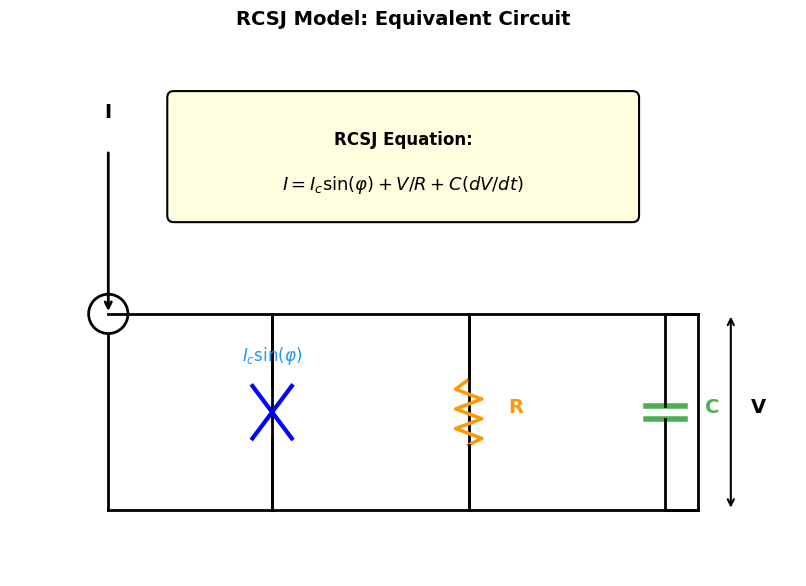

In [7]:
# Visualize: RCSJ equivalent circuit
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('RCSJ Model: Equivalent Circuit', fontsize=14, fontweight='bold', pad=20)

# Current source
ax.annotate('', xy=(1.5, 4), xytext=(1.5, 6.5), 
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(1.5, 7, 'I', fontsize=14, ha='center', fontweight='bold')
circle = Circle((1.5, 4), 0.3, fill=False, color='black', linewidth=2)
ax.add_patch(circle)

# Main horizontal lines
ax.plot([1.5, 10.5], [4, 4], 'k-', linewidth=2)  # Top
ax.plot([1.5, 10.5], [1, 1], 'k-', linewidth=2)  # Bottom
ax.plot([1.5, 1.5], [1, 3.7], 'k-', linewidth=2)  # Left vertical
ax.plot([10.5, 10.5], [1, 4], 'k-', linewidth=2)  # Right vertical

# Branch points
ax.plot([4, 4], [4, 1], 'k-', linewidth=2)
ax.plot([7, 7], [4, 1], 'k-', linewidth=2)

# Josephson element (X symbol)
jj_x, jj_y = 4, 2.5
ax.plot([jj_x-0.3, jj_x+0.3], [jj_y-0.4, jj_y+0.4], 'b-', linewidth=3)
ax.plot([jj_x-0.3, jj_x+0.3], [jj_y+0.4, jj_y-0.4], 'b-', linewidth=3)
ax.text(jj_x, jj_y + 0.8, '$I_c\\sin(\\varphi)$', fontsize=12, ha='center', color=COLORS['primary'])
ax.plot([jj_x, jj_x], [4, jj_y + 0.4], 'k-', linewidth=2)
ax.plot([jj_x, jj_x], [jj_y - 0.4, 1], 'k-', linewidth=2)

# Resistor
r_x, r_y = 7, 2.5
zigzag_x = [r_x, r_x-0.2, r_x+0.2, r_x-0.2, r_x+0.2, r_x-0.2, r_x+0.2, r_x]
zigzag_y = [r_y+0.5, r_y+0.35, r_y+0.2, r_y+0.05, r_y-0.1, r_y-0.25, r_y-0.4, r_y-0.5]
ax.plot(zigzag_x, zigzag_y, color=COLORS['secondary'], linewidth=2.5)
ax.text(r_x + 0.6, r_y, 'R', fontsize=14, color=COLORS['secondary'], fontweight='bold')
ax.plot([r_x, r_x], [4, r_y + 0.5], 'k-', linewidth=2)
ax.plot([r_x, r_x], [r_y - 0.5, 1], 'k-', linewidth=2)

# Capacitor
c_x, c_y = 10, 2.5
ax.plot([c_x-0.3, c_x+0.3], [c_y+0.1, c_y+0.1], color=COLORS['success'], linewidth=4)
ax.plot([c_x-0.3, c_x+0.3], [c_y-0.1, c_y-0.1], color=COLORS['success'], linewidth=4)
ax.text(c_x + 0.6, c_y, 'C', fontsize=14, color=COLORS['success'], fontweight='bold')
ax.plot([c_x, c_x], [4, c_y + 0.1], 'k-', linewidth=2)
ax.plot([c_x, c_x], [c_y - 0.1, 1], 'k-', linewidth=2)
ax.plot([10, 10.5], [4, 4], 'k-', linewidth=2)
ax.plot([10, 10.5], [1, 1], 'k-', linewidth=2)

# Voltage
ax.annotate('', xy=(11, 4), xytext=(11, 1),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(11.3, 2.5, 'V', fontsize=14, fontweight='bold')

# Equation box
eq_box = FancyBboxPatch((2.5, 5.5), 7, 1.8, boxstyle="round,pad=0.1",
                         facecolor='lightyellow', edgecolor='black', linewidth=1.5)
ax.add_patch(eq_box)
ax.text(6, 6.6, 'RCSJ Equation:', fontsize=12, ha='center', fontweight='bold')
ax.text(6, 5.9, '$I = I_c\\sin(\\varphi) + V/R + C(dV/dt)$', fontsize=13, ha='center')

plt.tight_layout()
plt.show()

### Stewart-McCumber Parameter

The **Stewart-McCumber parameter** $\beta_c$ determines the junction dynamics:

$$\boxed{\beta_c = \frac{2\pi I_c R^2 C}{\Phi_0} = \omega_c R C = \frac{R^2 C}{L_J}}$$

where:
- $\omega_c = 2\pi I_c R / \Phi_0$ is the characteristic frequency
- $L_J = \Phi_0 / (2\pi I_c)$ is the Josephson inductance

**Physical interpretation:** $\beta_c$ compares the RC time constant to the Josephson oscillation period.

| Regime | $\beta_c$ | Damping | I-V Behavior | Applications |
|--------|----------|---------|--------------|---------------|
| Overdamped | $<< 1$ | Strong | Non-hysteretic | SFQ logic, SQUIDs |
| Critical | $\approx 1$ | Moderate | Marginal hysteresis | Transition |
| Underdamped | $>> 1$ | Weak | Strongly hysteretic | Memory, latching |

In [8]:
# Calculate Stewart-McCumber parameter for various junction designs
def calc_beta_c(I_c, R, C):
    """Calculate Stewart-McCumber parameter."""
    return 2 * np.pi * I_c * R**2 * C / Phi_0

def calc_plasma_freq(I_c, C):
    """Calculate Josephson plasma frequency."""
    L_J = Phi_0 / (2 * np.pi * I_c)
    omega_p = 1 / np.sqrt(L_J * C)
    return omega_p / (2 * np.pi)

print("Stewart-McCumber Parameter Calculator")
print("=" * 60)

# Example junction designs
junctions = [
    ("Standard SIS (1 um^2)", 100e-6, 200, 50e-15),      # 100 uA, 200 ohm, 50 fF
    ("Shunted SIS", 100e-6, 5, 50e-15),                   # Same, but shunted to 5 ohm
    ("SNS junction", 500e-6, 1, 100e-15),                 # Higher Ic, lower R
    ("AQFP junction", 20e-6, 50, 30e-15),                 # Smaller for AQFP
]

print(f"{'Junction Type':<25} {'Ic (uA)':<10} {'R (ohm)':<10} {'C (fF)':<10} {'beta_c':<12} {'Regime'}")
print("-" * 80)

for name, Ic, R, C in junctions:
    beta_c = calc_beta_c(Ic, R, C)
    f_p = calc_plasma_freq(Ic, C)
    regime = "Overdamped" if beta_c < 0.7 else ("Critical" if beta_c < 1.5 else "Underdamped")
    print(f"{name:<25} {Ic*1e6:<10.0f} {R:<10.0f} {C*1e15:<10.0f} {beta_c:<12.2f} {regime}")

print()
print("Key insight: Adding a shunt resistor can convert a hysteretic junction to non-hysteretic.")

Stewart-McCumber Parameter Calculator
Junction Type             Ic (uA)    R (ohm)    C (fF)     beta_c       Regime
--------------------------------------------------------------------------------
Standard SIS (1 um^2)     100        200        50         607.71       Underdamped
Shunted SIS               100        5          50         0.38         Overdamped
SNS junction              500        1          100        0.15         Overdamped
AQFP junction             20         50         30         4.56         Underdamped

Key insight: Adding a shunt resistor can convert a hysteretic junction to non-hysteretic.


### The Washboard Potential Analogy

The RCSJ equation is mathematically equivalent to a **particle in a tilted washboard potential**:

$$U(\varphi) = -E_J\cos(\varphi) - \frac{\Phi_0 I}{2\pi}\varphi$$

where $E_J = I_c \Phi_0 / 2\pi$ is the **Josephson energy**.

| Electrical | Mechanical Analog |
|------------|-------------------|
| Phase $\varphi$ | Position |
| Voltage $V \propto d\varphi/dt$ | Velocity |
| Capacitance $C$ | Mass |
| Conductance $1/R$ | Damping (friction) |
| Bias current $I$ | Tilt of washboard |
| Critical current $I_c$ | Height of potential bumps |

**Key behaviors:**
- $I < I_c$: Particle trapped in a potential well (zero voltage)
- $I = I_c$: Wells disappear, particle starts rolling (switching)
- $I > I_c$: Particle rolls down, oscillating (voltage state)

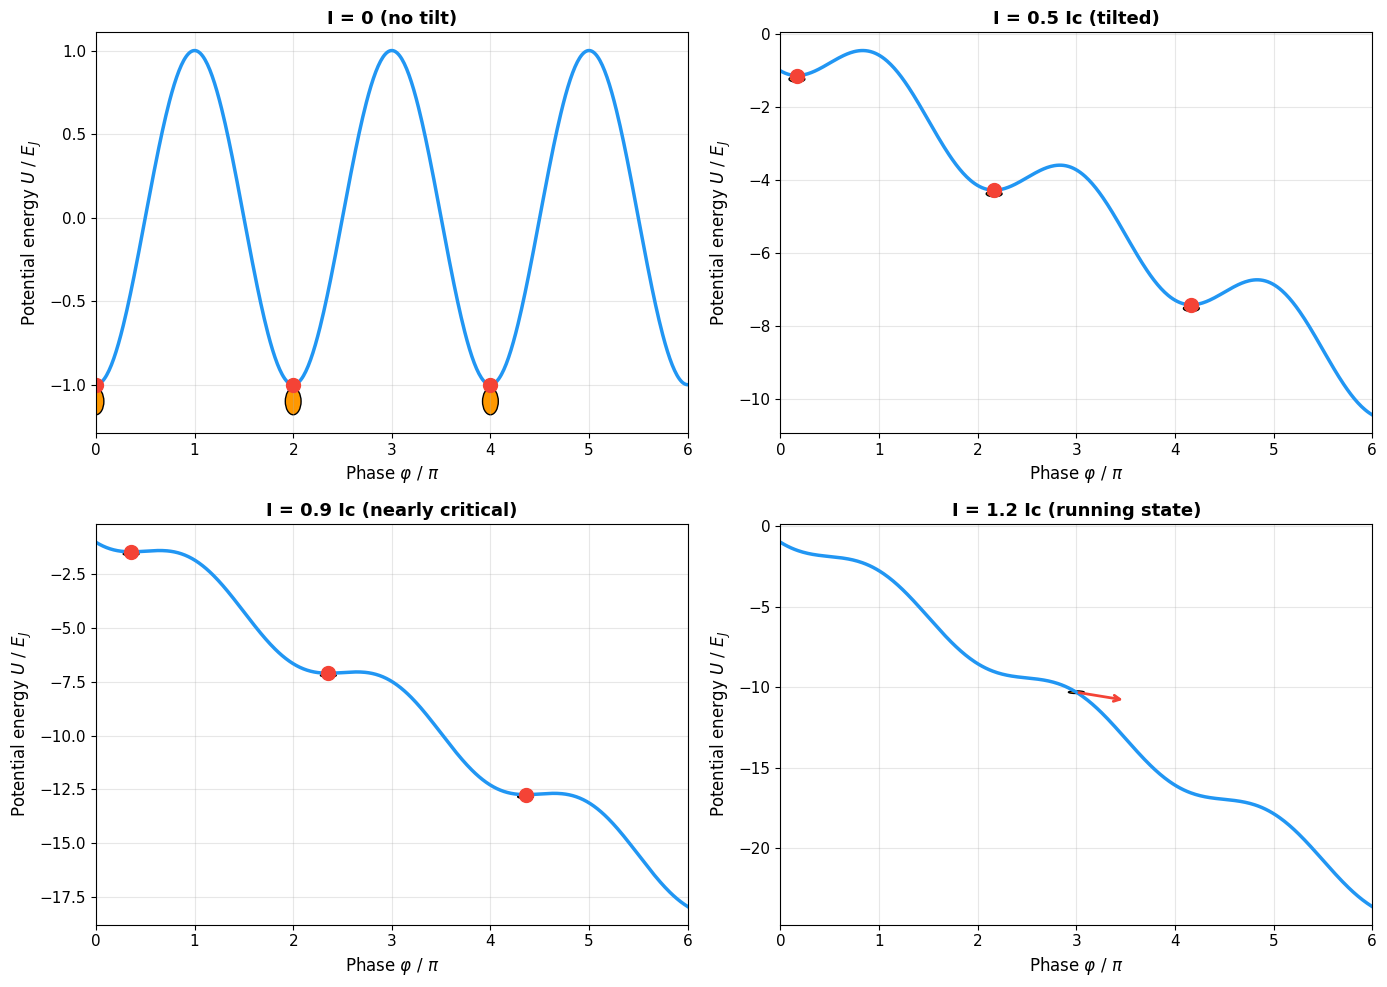

Washboard analogy:
- The 'ball' represents the phase of the junction
- Bias current tilts the washboard
- At I > Ic, the ball escapes and 'rolls down' = voltage state


In [9]:
# Visualize: Washboard potential at different bias currents
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

phi = np.linspace(0, 6*np.pi, 500)
E_J = 1  # Normalized Josephson energy

bias_currents = [0, 0.5, 0.9, 1.2]  # Normalized to Ic
titles = ['I = 0 (no tilt)', 'I = 0.5 Ic (tilted)', 
          'I = 0.9 Ic (nearly critical)', 'I = 1.2 Ic (running state)']

for ax, i_bias, title in zip(axes.flat, bias_currents, titles):
    # Washboard potential: U = -E_J*cos(phi) - (I/Ic)*E_J*phi
    U = -E_J * np.cos(phi) - i_bias * E_J * phi
    
    ax.plot(phi/np.pi, U, color=COLORS['primary'], linewidth=2.5)
    
    # Find and mark local minima (trapped states)
    if i_bias < 1:
        # Analytical positions of minima
        for n in range(3):
            phi_min = np.arcsin(i_bias) + 2*np.pi*n
            if phi_min < phi[-1]:
                U_min = -E_J * np.cos(phi_min) - i_bias * E_J * phi_min
                ax.plot(phi_min/np.pi, U_min, 'o', color=COLORS['danger'], markersize=10)
                
                # Draw ball in well
                circle = Circle((phi_min/np.pi, U_min - 0.1), 0.08, 
                               facecolor=COLORS['secondary'], edgecolor='black')
                ax.add_patch(circle)
    else:
        # Running state - show particle with arrow
        phi_pos = 3
        U_pos = -E_J * np.cos(phi_pos*np.pi) - i_bias * E_J * phi_pos * np.pi
        circle = Circle((phi_pos, U_pos), 0.08, 
                        facecolor=COLORS['secondary'], edgecolor='black')
        ax.add_patch(circle)
        ax.annotate('', xy=(phi_pos + 0.5, U_pos - 0.5), xytext=(phi_pos, U_pos),
                   arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
    
    ax.set_xlabel('Phase $\\varphi$ / $\\pi$', fontsize=12)
    ax.set_ylabel('Potential energy $U$ / $E_J$', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Washboard analogy:")
print("- The 'ball' represents the phase of the junction")
print("- Bias current tilts the washboard")
print("- At I > Ic, the ball escapes and 'rolls down' = voltage state")

Computing I-V curves (this may take a moment)...


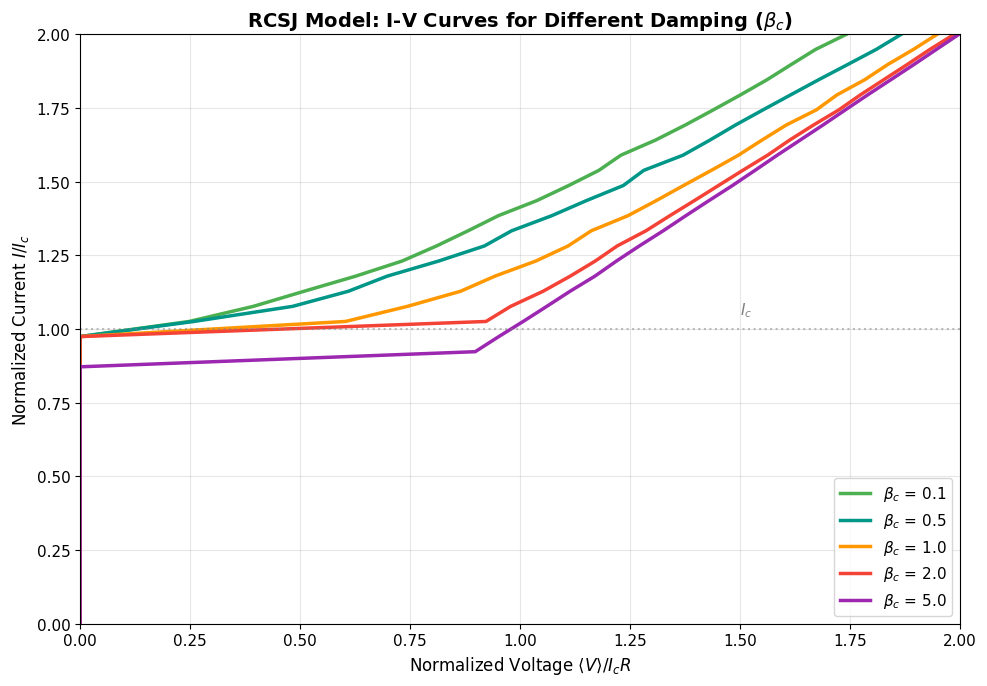


Observations:
- Small beta_c (overdamped): Smooth transition at Ic
- Large beta_c (underdamped): Sharp transition, approaches ohmic line quickly


In [10]:
# Simulate RCSJ dynamics: I-V curves for different beta_c
def rcsj_derivatives(y, t, I_bias_norm, beta_c):
    """
    RCSJ model in normalized form.
    y[0] = phi (phase)
    y[1] = dphi/dt (proportional to voltage)
    
    Normalized equation: beta_c * d2phi/dt2 + dphi/dt + sin(phi) = I/Ic
    """
    phi, dphi_dt = y
    d2phi_dt2 = (I_bias_norm - np.sin(phi) - dphi_dt) / beta_c
    return [dphi_dt, d2phi_dt2]

def compute_iv_curve(beta_c, I_max=2.0, n_points=50):
    """Compute I-V curve for given beta_c."""
    I_values = np.linspace(0, I_max, n_points)
    V_values = []
    
    for I_bias in I_values:
        # Time span (normalized)
        t = np.linspace(0, 500, 5000)
        
        # Initial conditions
        y0 = [0, 0]
        
        # Solve ODE
        solution = odeint(rcsj_derivatives, y0, t, args=(I_bias, beta_c))
        
        # Average voltage (proportional to dphi/dt) in steady state
        V_avg = np.mean(solution[-1000:, 1])  # Last portion for steady state
        V_values.append(V_avg)
    
    return np.array(I_values), np.array(V_values)

# Compute I-V curves for different beta_c values
fig, ax = plt.subplots(figsize=(10, 7))

beta_c_values = [0.1, 0.5, 1.0, 2.0, 5.0]
colors = [COLORS['success'], COLORS['teal'], COLORS['secondary'], 
          COLORS['danger'], COLORS['purple']]

print("Computing I-V curves (this may take a moment)...")
for beta_c, color in zip(beta_c_values, colors):
    I, V = compute_iv_curve(beta_c, I_max=2.0, n_points=40)
    ax.plot(V, I, '-', color=color, linewidth=2.5, label=f'$\\beta_c$ = {beta_c}')

ax.axhline(1, color='gray', linestyle=':', alpha=0.5)
ax.text(1.5, 1.05, '$I_c$', fontsize=11, color='gray')

ax.set_xlabel('Normalized Voltage $\\langle V \\rangle / I_c R$', fontsize=12)
ax.set_ylabel('Normalized Current $I / I_c$', fontsize=12)
ax.set_title('RCSJ Model: I-V Curves for Different Damping ($\\beta_c$)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Small beta_c (overdamped): Smooth transition at Ic")
print("- Large beta_c (underdamped): Sharp transition, approaches ohmic line quickly")

---
<a id="4-junction-types"></a>
# 4. Junction Types
---

Different junction structures offer different trade-offs in terms of critical current, resistance, damping, and ease of fabrication.

### SIS Junctions (Superconductor-Insulator-Superconductor)

The most common type, exemplified by **Nb/Al-AlO_x/Nb**:

- **Barrier**: Thin oxide (1-2 nm AlO_x)
- **I_cR_n product**: Highest (~1.9 mV for Nb)
- **Capacitance**: 40-100 fF/um^2 (intrinsically high)
- **Damping**: Typically underdamped ($\beta_c >> 1$) without external shunt
- **Advantages**: Well-controlled, reproducible, high voltage swing
- **Disadvantages**: Requires shunting for non-hysteretic operation

### Comparison of Junction Types

| Type | Structure | I_cR_n | Typical beta_c | Advantages | Disadvantages |
|------|-----------|--------|----------------|------------|---------------|
| **SIS** | S-Insulator-S | High (~1.9 mV) | >> 1 | High voltage, reproducible | Hysteretic, complex fab |
| **SNS** | S-Normal metal-S | Low (~0.1 mV) | << 1 | Non-hysteretic, simple | Low voltage swing |
| **SFS** | S-Ferromagnet-S | Variable | Variable | pi-junctions possible | Complex, lower I_c |
| **ScS** | S-constriction-S | Moderate | Variable | Simple geometry | Less reproducible |

### SNS Junctions (Superconductor-Normal metal-Superconductor)

- **Barrier**: Normal metal (Cu, Au, Pd)
- **Mechanism**: Proximity effect carries supercurrent through normal metal
- **I_cR_n product**: Lower than SIS
- **Damping**: Inherently overdamped (low R)
- **Applications**: SQUIDs, some SFQ circuits

### SFS Junctions and Pi-Junctions

- **Barrier**: Ferromagnetic material
- **Special feature**: Can create **pi-junctions** where ground state has $\varphi = \pi$
- **Current-phase relation**: $I = -I_c \sin(\varphi) = I_c \sin(\varphi + \pi)$
- **Applications**: Phase shifters, quantum computing, novel logic

### Weak Links and Microbridges

- **Structure**: Narrow constriction in superconducting film
- **No explicit barrier**: Weak link arises from geometry
- **Advantages**: Simple fabrication, scalable
- **Challenges**: Less reproducible than trilayer junctions

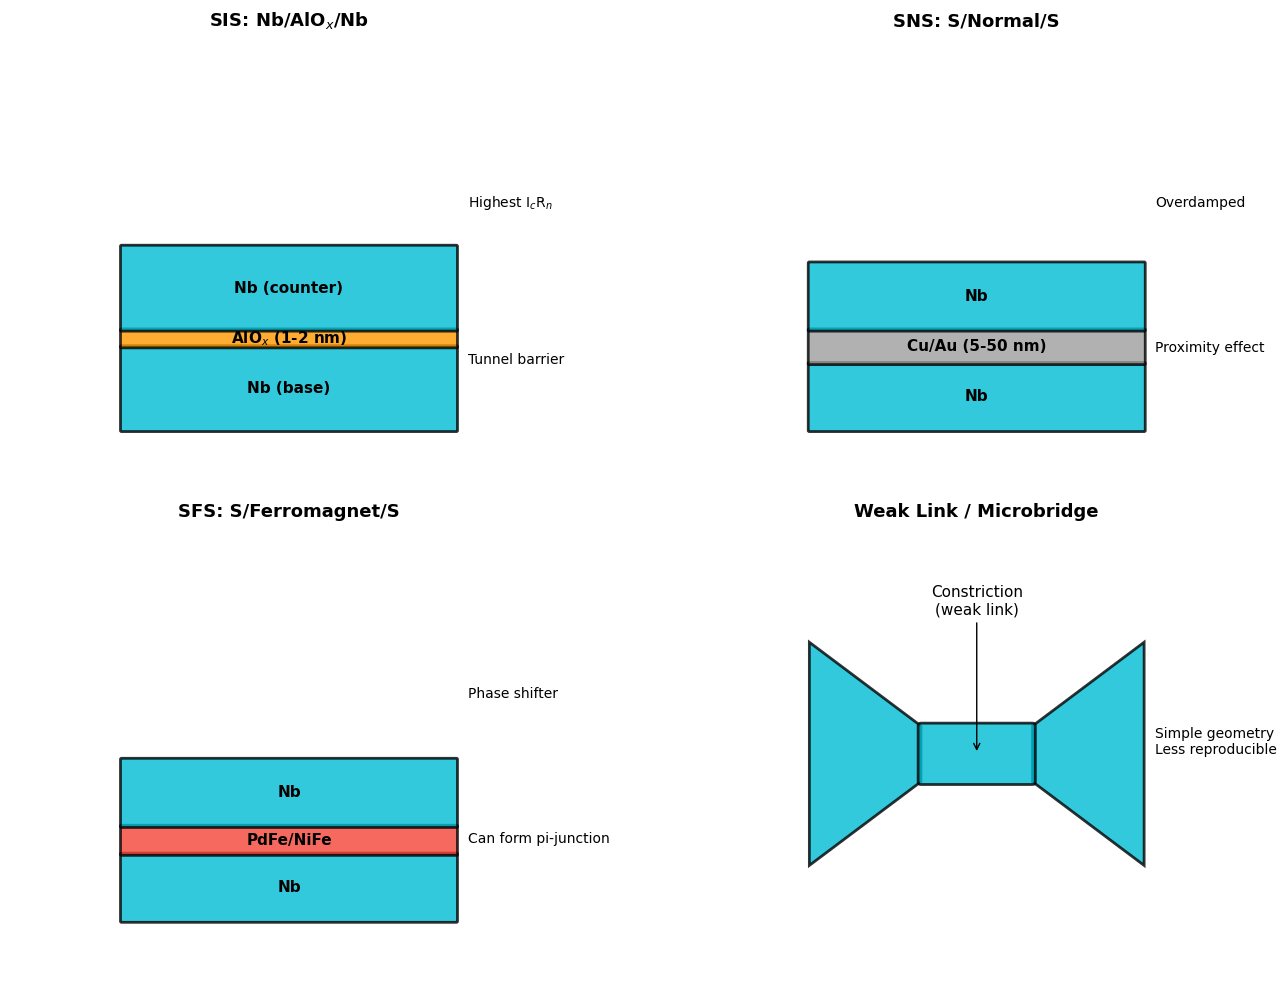

In [11]:
# Visualize: Different junction structures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def draw_junction(ax, layers, title, annotations):
    """Draw a schematic of junction layers."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    
    y_pos = 1
    for layer_name, height, color in layers:
        rect = FancyBboxPatch((2, y_pos), 6, height, boxstyle="round,pad=0.02",
                               facecolor=color, edgecolor='black', linewidth=2, alpha=0.8)
        ax.add_patch(rect)
        ax.text(5, y_pos + height/2, layer_name, fontsize=11, ha='center', va='center', fontweight='bold')
        y_pos += height
    
    # Add annotations
    for text, pos in annotations:
        ax.text(pos[0], pos[1], text, fontsize=10, ha='left')

# SIS junction
sis_layers = [
    ('Nb (base)', 1.5, COLORS['superconducting']),
    ('AlO$_x$ (1-2 nm)', 0.3, COLORS['secondary']),
    ('Nb (counter)', 1.5, COLORS['superconducting'])
]
draw_junction(axes[0, 0], sis_layers, 'SIS: Nb/AlO$_x$/Nb', 
              [('Tunnel barrier', (8.2, 2.2)), ('Highest I$_c$R$_n$', (8.2, 5))])

# SNS junction  
sns_layers = [
    ('Nb', 1.2, COLORS['superconducting']),
    ('Cu/Au (5-50 nm)', 0.6, COLORS['normal']),
    ('Nb', 1.2, COLORS['superconducting'])
]
draw_junction(axes[0, 1], sns_layers, 'SNS: S/Normal/S',
              [('Proximity effect', (8.2, 2.4)), ('Overdamped', (8.2, 5))])

# SFS junction
sfs_layers = [
    ('Nb', 1.2, COLORS['superconducting']),
    ('PdFe/NiFe', 0.5, COLORS['danger']),
    ('Nb', 1.2, COLORS['superconducting'])
]
draw_junction(axes[1, 0], sfs_layers, 'SFS: S/Ferromagnet/S',
              [('Can form pi-junction', (8.2, 2.4)), ('Phase shifter', (8.2, 5))])

# Microbridge
ax = axes[1, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Weak Link / Microbridge', fontsize=13, fontweight='bold', pad=10)

# Draw hourglass shape
from matplotlib.patches import Polygon
left_pad = Polygon([(2, 2), (4, 3.5), (4, 4.5), (2, 6)], closed=True,
                   facecolor=COLORS['superconducting'], edgecolor='black', linewidth=2, alpha=0.8)
right_pad = Polygon([(8, 2), (6, 3.5), (6, 4.5), (8, 6)], closed=True,
                    facecolor=COLORS['superconducting'], edgecolor='black', linewidth=2, alpha=0.8)
bridge = FancyBboxPatch((4, 3.5), 2, 1, boxstyle="round,pad=0.05",
                        facecolor=COLORS['superconducting'], edgecolor='black', linewidth=2, alpha=0.8)
ax.add_patch(left_pad)
ax.add_patch(right_pad)
ax.add_patch(bridge)

ax.annotate('Constriction\n(weak link)', xy=(5, 4), xytext=(5, 6.5),
           arrowprops=dict(arrowstyle='->', color='black'), fontsize=11, ha='center')
ax.text(8.2, 4, 'Simple geometry\nLess reproducible', fontsize=10, ha='left')

plt.tight_layout()
plt.show()

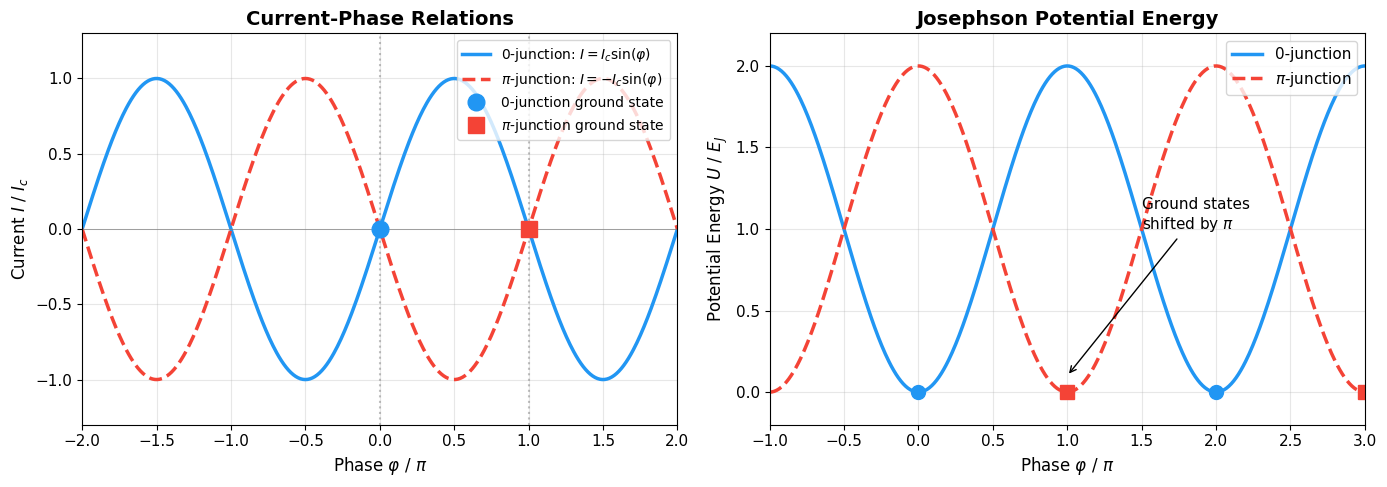

Pi-junctions are used for:
- Phase shifters in superconducting circuits
- Compact flux bias in SQUID loops
- Novel qubit designs (phase qubits, pi-qubits)


In [12]:
# Visualize: Standard vs pi-junction current-phase relations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

phi = np.linspace(-2*np.pi, 2*np.pi, 500)

# Standard (0-junction)
I_0 = np.sin(phi)
ax1.plot(phi/np.pi, I_0, color=COLORS['primary'], linewidth=2.5, label='0-junction: $I = I_c\\sin(\\varphi)$')

# Pi-junction
I_pi = -np.sin(phi)  # = sin(phi + pi)
ax1.plot(phi/np.pi, I_pi, color=COLORS['danger'], linewidth=2.5, linestyle='--', 
         label='$\\pi$-junction: $I = -I_c\\sin(\\varphi)$')

ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(1, color='gray', linestyle=':', alpha=0.5)

# Mark ground states
ax1.plot([0], [0], 'o', color=COLORS['primary'], markersize=12, label='0-junction ground state')
ax1.plot([1], [0], 's', color=COLORS['danger'], markersize=12, label='$\\pi$-junction ground state')

ax1.set_xlabel('Phase $\\varphi$ / $\\pi$', fontsize=12)
ax1.set_ylabel('Current $I$ / $I_c$', fontsize=12)
ax1.set_title('Current-Phase Relations', fontsize=14, fontweight='bold')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1.3, 1.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Potential energy comparison
phi_pot = np.linspace(-np.pi, 3*np.pi, 500)
U_0 = 1 - np.cos(phi_pot)  # Standard: minima at 0, 2pi
U_pi = 1 + np.cos(phi_pot)  # Pi: minima at pi, 3pi

ax2.plot(phi_pot/np.pi, U_0, color=COLORS['primary'], linewidth=2.5, label='0-junction')
ax2.plot(phi_pot/np.pi, U_pi, color=COLORS['danger'], linewidth=2.5, linestyle='--', label='$\\pi$-junction')

# Mark minima
ax2.plot([0, 2], [0, 0], 'o', color=COLORS['primary'], markersize=10)
ax2.plot([1, 3], [0, 0], 's', color=COLORS['danger'], markersize=10)

ax2.set_xlabel('Phase $\\varphi$ / $\\pi$', fontsize=12)
ax2.set_ylabel('Potential Energy $U$ / $E_J$', fontsize=12)
ax2.set_title('Josephson Potential Energy', fontsize=14, fontweight='bold')
ax2.set_xlim(-1, 3)
ax2.set_ylim(-0.2, 2.2)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

ax2.annotate('Ground states\nshifted by $\\pi$', xy=(1, 0.1), xytext=(1.5, 1),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

plt.tight_layout()
plt.show()

print("Pi-junctions are used for:")
print("- Phase shifters in superconducting circuits")
print("- Compact flux bias in SQUID loops")
print("- Novel qubit designs (phase qubits, pi-qubits)")

---
<a id="5-key-parameters"></a>
# 5. Key Parameters
---

Understanding and controlling junction parameters is essential for circuit design.

### Critical Current (I_c)

The maximum supercurrent the junction can carry:

$$I_c = J_c \times A$$

where $J_c$ is the critical current density and $A$ is the junction area.

| Parameter | Typical Values | Control Method |
|-----------|---------------|----------------|
| $J_c$ | 0.1 - 100 kA/cm^2 | Barrier oxidation |
| Junction area | 0.1 - 10 um^2 | Lithography |
| $I_c$ | 10 uA - 10 mA | Both above |

### Normal Resistance (R_n)

Resistance in the voltage state (above gap):

$$R_n = \frac{\rho_n \cdot d}{A}$$

where $\rho_n$ is the specific barrier resistance and $d$ is the barrier thickness.

For tunnel junctions: $R_n \propto e^{d/d_0}$ (exponential dependence on thickness)

### The I_cR_n Product

A fundamental figure of merit that depends only on the superconducting materials:

$$\boxed{I_c R_n = V_c \approx \frac{\pi \Delta}{2e}}$$

This is the **characteristic voltage**, setting the voltage scale for junction operation.

| Material | Gap $\Delta$ (meV) | $I_cR_n$ (mV) | Characteristic Frequency |
|----------|-------------------|---------------|-------------------------|
| Nb | 1.4 | 1.9 | 920 GHz |
| NbN | 2.5 | 3.9 | 1.9 THz |
| Al | 0.17 | 0.27 | 130 GHz |

**Key insight**: $I_cR_n$ is independent of junction area. Larger junctions have higher $I_c$ but proportionally lower $R_n$.

In [13]:
# Junction parameter calculator
def junction_parameters(J_c_kAcm2, area_um2, Delta_mV, C_per_area_fF=50):
    """
    Calculate junction parameters.
    
    J_c_kAcm2: Critical current density in kA/cm^2
    area_um2: Junction area in um^2
    Delta_mV: Superconducting gap in mV
    C_per_area_fF: Specific capacitance in fF/um^2
    """
    # Convert units
    J_c = J_c_kAcm2 * 1e3 * 1e4  # A/m^2
    A = area_um2 * 1e-12  # m^2
    Delta = Delta_mV * 1e-3  # V
    
    # Critical current
    I_c = J_c * A
    
    # IcRn product (theoretical)
    V_c = np.pi * Delta / 2
    
    # Normal resistance
    R_n = V_c / I_c
    
    # Capacitance
    C = C_per_area_fF * area_um2 * 1e-15  # F
    
    # Stewart-McCumber parameter
    beta_c = 2 * np.pi * I_c * R_n**2 * C / Phi_0
    
    # Josephson inductance
    L_J = Phi_0 / (2 * np.pi * I_c)
    
    # Characteristic frequency
    f_c = V_c / Phi_0
    
    # Plasma frequency
    omega_p = 1 / np.sqrt(L_J * C)
    f_p = omega_p / (2 * np.pi)
    
    return {
        'I_c': I_c,
        'R_n': R_n,
        'V_c': V_c,
        'C': C,
        'beta_c': beta_c,
        'L_J': L_J,
        'f_c': f_c,
        'f_p': f_p
    }

# Example: Typical Nb/Al-AlOx/Nb junction
print("Josephson Junction Parameter Calculator")
print("=" * 60)
print("\nExample: Nb/Al-AlOx/Nb junction")
print("-" * 60)

# Input parameters
J_c = 1.0       # kA/cm^2
area = 1.0      # um^2
Delta = 1.4     # mV (Nb gap)
C_spec = 50     # fF/um^2

print(f"Input: J_c = {J_c} kA/cm^2, Area = {area} um^2, Delta = {Delta} mV")
print(f"       Specific capacitance = {C_spec} fF/um^2")
print()

params = junction_parameters(J_c, area, Delta, C_spec)

print("Calculated Parameters:")
print(f"  Critical current:     I_c = {params['I_c']*1e6:.1f} uA")
print(f"  Normal resistance:    R_n = {params['R_n']:.1f} ohm")
print(f"  IcRn product:         V_c = {params['V_c']*1e3:.2f} mV")
print(f"  Capacitance:          C   = {params['C']*1e15:.1f} fF")
print(f"  Stewart-McCumber:     beta_c = {params['beta_c']:.1f}")
print(f"  Josephson inductance: L_J = {params['L_J']*1e12:.2f} pH")
print(f"  Characteristic freq:  f_c = {params['f_c']/1e9:.0f} GHz")
print(f"  Plasma frequency:     f_p = {params['f_p']/1e9:.1f} GHz")
print()
regime = "Overdamped" if params['beta_c'] < 0.7 else ("Critical" if params['beta_c'] < 1.5 else "Underdamped")
print(f"  Damping regime: {regime}")

Josephson Junction Parameter Calculator

Example: Nb/Al-AlOx/Nb junction
------------------------------------------------------------
Input: J_c = 1.0 kA/cm^2, Area = 1.0 um^2, Delta = 1.4 mV
       Specific capacitance = 50 fF/um^2

Calculated Parameters:
  Critical current:     I_c = 10.0 uA
  Normal resistance:    R_n = 219.9 ohm
  IcRn product:         V_c = 2.20 mV
  Capacitance:          C   = 50.0 fF
  Stewart-McCumber:     beta_c = 73.5
  Josephson inductance: L_J = 32.91 pH
  Characteristic freq:  f_c = 1063 GHz
  Plasma frequency:     f_p = 124.1 GHz

  Damping regime: Underdamped


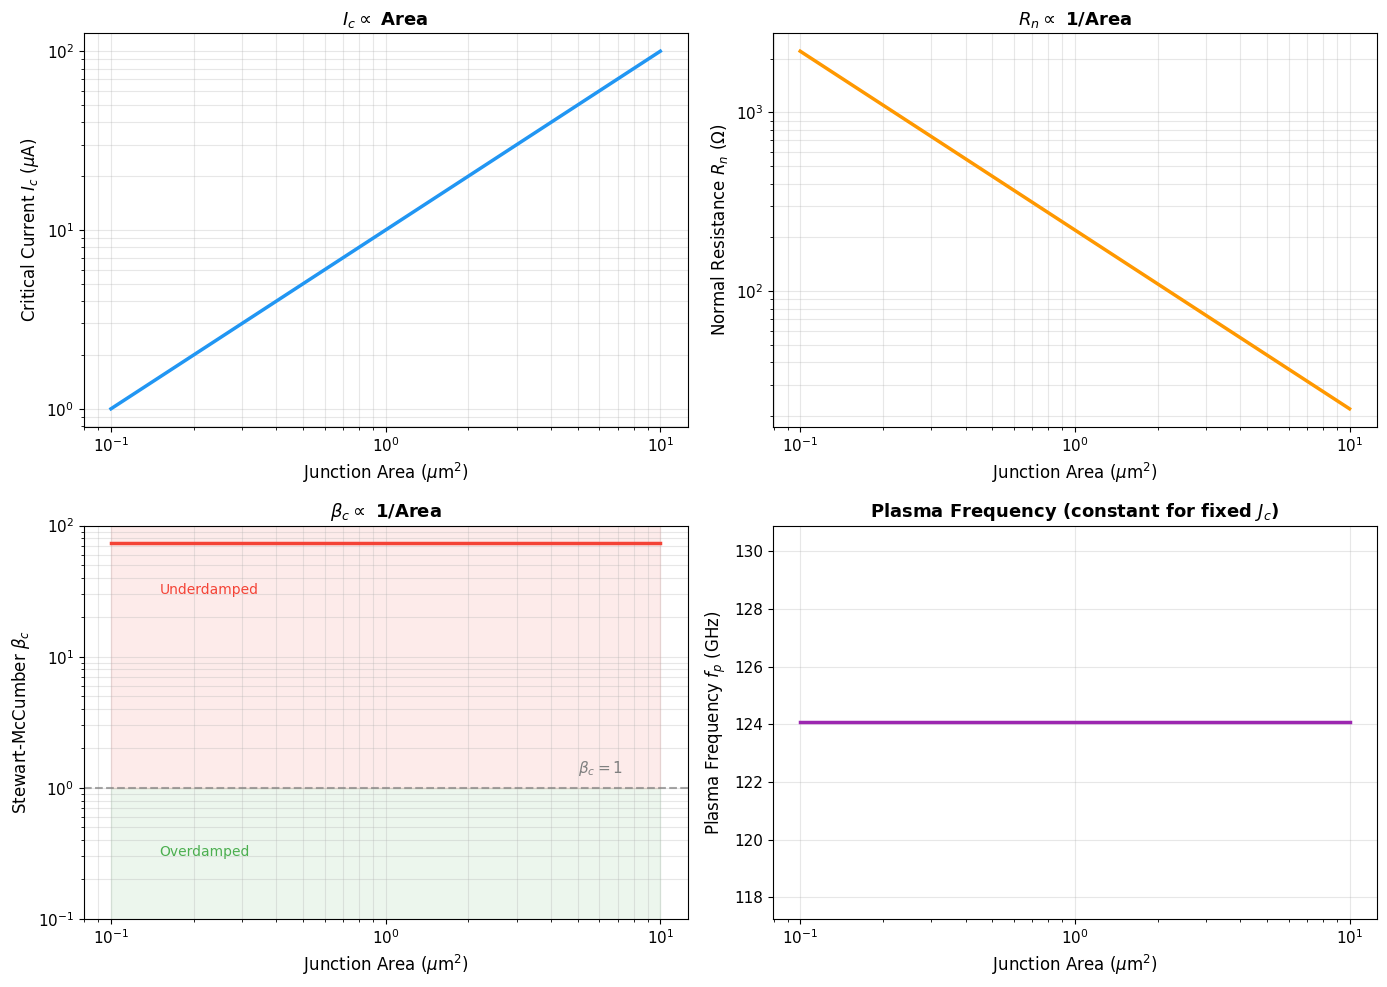

Key scaling relationships:
- I_c scales linearly with area
- R_n scales inversely with area
- I_c * R_n = constant (independent of area!)
- beta_c scales inversely with area (smaller junctions are more hysteretic)
- f_p is constant for fixed J_c and specific capacitance


In [14]:
# Visualize: How parameters scale with junction area
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

areas = np.logspace(-1, 1, 50)  # 0.1 to 10 um^2
J_c = 1.0  # kA/cm^2
Delta = 1.4  # mV

# Calculate parameters for each area
I_c_vals = []
R_n_vals = []
beta_c_vals = []
f_p_vals = []

for A in areas:
    p = junction_parameters(J_c, A, Delta)
    I_c_vals.append(p['I_c'] * 1e6)  # uA
    R_n_vals.append(p['R_n'])  # ohm
    beta_c_vals.append(p['beta_c'])
    f_p_vals.append(p['f_p'] / 1e9)  # GHz

# Plot Ic vs area
ax = axes[0, 0]
ax.loglog(areas, I_c_vals, color=COLORS['primary'], linewidth=2.5)
ax.set_xlabel('Junction Area ($\\mu$m$^2$)', fontsize=12)
ax.set_ylabel('Critical Current $I_c$ ($\\mu$A)', fontsize=12)
ax.set_title('$I_c \\propto$ Area', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot Rn vs area
ax = axes[0, 1]
ax.loglog(areas, R_n_vals, color=COLORS['secondary'], linewidth=2.5)
ax.set_xlabel('Junction Area ($\\mu$m$^2$)', fontsize=12)
ax.set_ylabel('Normal Resistance $R_n$ ($\\Omega$)', fontsize=12)
ax.set_title('$R_n \\propto$ 1/Area', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot beta_c vs area
ax = axes[1, 0]
ax.loglog(areas, beta_c_vals, color=COLORS['danger'], linewidth=2.5)
ax.axhline(1, color='gray', linestyle='--', alpha=0.7)
ax.text(5, 1.3, '$\\beta_c = 1$', fontsize=11, color='gray')
ax.fill_between(areas, 0.01, 1, alpha=0.1, color=COLORS['success'])
ax.fill_between(areas, 1, 100, alpha=0.1, color=COLORS['danger'])
ax.text(0.15, 0.3, 'Overdamped', fontsize=10, color=COLORS['success'])
ax.text(0.15, 30, 'Underdamped', fontsize=10, color=COLORS['danger'])
ax.set_xlabel('Junction Area ($\\mu$m$^2$)', fontsize=12)
ax.set_ylabel('Stewart-McCumber $\\beta_c$', fontsize=12)
ax.set_title('$\\beta_c \\propto$ 1/Area', fontsize=13, fontweight='bold')
ax.set_ylim(0.1, 100)
ax.grid(True, alpha=0.3, which='both')

# Plot plasma frequency vs area
ax = axes[1, 1]
ax.semilogx(areas, f_p_vals, color=COLORS['purple'], linewidth=2.5)
ax.set_xlabel('Junction Area ($\\mu$m$^2$)', fontsize=12)
ax.set_ylabel('Plasma Frequency $f_p$ (GHz)', fontsize=12)
ax.set_title('Plasma Frequency (constant for fixed $J_c$)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key scaling relationships:")
print("- I_c scales linearly with area")
print("- R_n scales inversely with area")
print("- I_c * R_n = constant (independent of area!)")
print("- beta_c scales inversely with area (smaller junctions are more hysteretic)")
print("- f_p is constant for fixed J_c and specific capacitance")

### Junction Capacitance

The junction capacitance has two main contributions:

1. **Geometric capacitance**: Parallel plate capacitor formed by the electrodes
   $$C_{geo} = \epsilon_0 \epsilon_r \frac{A}{d}$$

2. **Kinetic inductance contribution**: Small correction from Cooper pair tunneling

For typical SIS tunnel junctions:

| Barrier | Thickness | Dielectric Constant | Specific Capacitance |
|---------|-----------|---------------------|---------------------|
| AlO$_x$ | 1-2 nm | ~10 | 40-100 fF/$\mu$m$^2$ |
| MgO | 1-2 nm | ~9 | 35-90 fF/$\mu$m$^2$ |

**Design consideration**: Higher $J_c$ (thinner barrier) generally means higher specific capacitance.

---
<a id="6-fabrication"></a>
# 6. Fabrication Overview
---

The most widely used process for Josephson junction fabrication is the **Nb/Al-AlO$_x$/Nb trilayer process**.

### Process Steps

1. **Substrate preparation**
   - Silicon or sapphire wafer
   - Thermal oxide or deposited dielectric

2. **Trilayer deposition** (in-situ, without breaking vacuum)
   - Nb base electrode (~150-200 nm)
   - Al wetting layer (~5-10 nm)
   - Controlled oxidation to form AlO$_x$ barrier
   - Nb counter electrode (~100-150 nm)

3. **Junction definition**
   - Various methods: anodization, selective Nb etch (SNEP), or RIE
   - Creates isolated junction area

4. **Wiring and interconnects**
   - Additional Nb or NbN layers
   - Insulating layers (SiO$_2$) between wiring levels

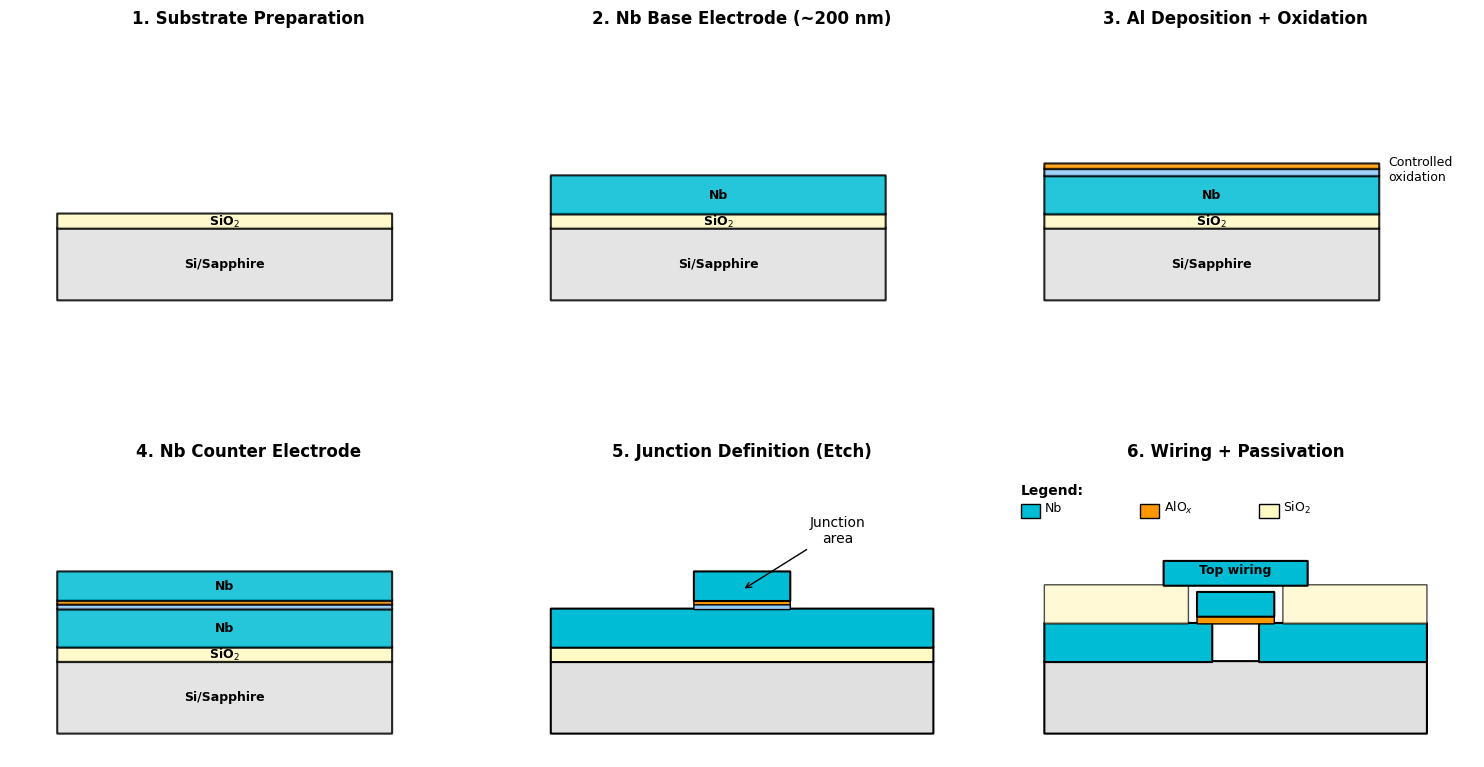

In [15]:
# Visualize: Trilayer fabrication process
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def draw_fab_step(ax, title, layers, annotations=[]):
    """Draw a fabrication step."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    y = 0.5
    for layer_def in layers:
        if len(layer_def) == 4:
            name, height, color, x_range = layer_def
        else:
            name, height, color = layer_def
            x_range = (1, 8)
        
        width = x_range[1] - x_range[0]
        rect = FancyBboxPatch((x_range[0], y), width, height, boxstyle="round,pad=0.01",
                               facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
        ax.add_patch(rect)
        if name and height > 0.2:
            ax.text(x_range[0] + width/2, y + height/2, name, fontsize=9, 
                   ha='center', va='center', fontweight='bold')
        y += height
    
    for text, pos in annotations:
        ax.text(pos[0], pos[1], text, fontsize=9)

# Color scheme for layers
c_sub = '#E0E0E0'  # Substrate
c_nb = COLORS['superconducting']  # Niobium
c_al = '#90CAF9'  # Aluminum
c_ox = COLORS['secondary']  # Oxide
c_ins = '#FFF9C4'  # Insulator

# Step 1: Substrate
draw_fab_step(axes[0, 0], '1. Substrate Preparation',
              [('Si/Sapphire', 1.5, c_sub),
               ('SiO$_2$', 0.3, c_ins)])

# Step 2: Base Nb
draw_fab_step(axes[0, 1], '2. Nb Base Electrode (~200 nm)',
              [('Si/Sapphire', 1.5, c_sub),
               ('SiO$_2$', 0.3, c_ins),
               ('Nb', 0.8, c_nb)])

# Step 3: Al + Oxidation
draw_fab_step(axes[0, 2], '3. Al Deposition + Oxidation',
              [('Si/Sapphire', 1.5, c_sub),
               ('SiO$_2$', 0.3, c_ins),
               ('Nb', 0.8, c_nb),
               ('Al (5 nm)', 0.15, c_al),
               ('AlO$_x$', 0.1, c_ox)],
              [('Controlled\noxidation', (8.2, 3))])

# Step 4: Counter electrode
draw_fab_step(axes[1, 0], '4. Nb Counter Electrode',
              [('Si/Sapphire', 1.5, c_sub),
               ('SiO$_2$', 0.3, c_ins),
               ('Nb', 0.8, c_nb),
               ('Al', 0.1, c_al),
               ('AlO$_x$', 0.08, c_ox),
               ('Nb', 0.6, c_nb)])

# Step 5: Junction definition
ax = axes[1, 1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('5. Junction Definition (Etch)', fontsize=12, fontweight='bold', pad=10)

# Base layers
rect = FancyBboxPatch((1, 0.5), 8, 1.5, boxstyle="round,pad=0.01",
                       facecolor=c_sub, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)
rect = FancyBboxPatch((1, 2.0), 8, 0.3, boxstyle="round,pad=0.01",
                       facecolor=c_ins, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)
rect = FancyBboxPatch((1, 2.3), 8, 0.8, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

# Junction (narrow)
rect = FancyBboxPatch((4, 3.1), 2, 0.1, boxstyle="round,pad=0.01",
                       facecolor=c_al, edgecolor='black', linewidth=1)
ax.add_patch(rect)
rect = FancyBboxPatch((4, 3.2), 2, 0.08, boxstyle="round,pad=0.01",
                       facecolor=c_ox, edgecolor='black', linewidth=1)
ax.add_patch(rect)
rect = FancyBboxPatch((4, 3.28), 2, 0.6, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

ax.annotate('Junction\narea', xy=(5, 3.5), xytext=(7, 4.5),
           arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, ha='center')

# Step 6: Complete structure
ax = axes[1, 2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('6. Wiring + Passivation', fontsize=12, fontweight='bold', pad=10)

# Base layers
rect = FancyBboxPatch((1, 0.5), 8, 1.5, boxstyle="round,pad=0.01",
                       facecolor=c_sub, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

# Base Nb (patterned)
rect = FancyBboxPatch((1, 2.0), 3.5, 0.8, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)
rect = FancyBboxPatch((5.5, 2.0), 3.5, 0.8, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

# Junction
rect = FancyBboxPatch((4.2, 2.8), 1.6, 0.15, boxstyle="round,pad=0.01",
                       facecolor=c_ox, edgecolor='black', linewidth=1)
ax.add_patch(rect)
rect = FancyBboxPatch((4.2, 2.95), 1.6, 0.5, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

# Insulator
rect = FancyBboxPatch((1, 2.8), 3, 0.8, boxstyle="round,pad=0.01",
                       facecolor=c_ins, edgecolor='black', linewidth=1, alpha=0.7)
ax.add_patch(rect)
rect = FancyBboxPatch((6, 2.8), 3, 0.8, boxstyle="round,pad=0.01",
                       facecolor=c_ins, edgecolor='black', linewidth=1, alpha=0.7)
ax.add_patch(rect)

# Top wiring
rect = FancyBboxPatch((3.5, 3.6), 3, 0.5, boxstyle="round,pad=0.01",
                       facecolor=c_nb, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)
ax.text(5, 3.85, 'Top wiring', fontsize=9, ha='center', fontweight='bold')

# Legend
ax.text(0.5, 5.5, 'Legend:', fontsize=10, fontweight='bold')
legend_items = [('Nb', c_nb), ('AlO$_x$', c_ox), ('SiO$_2$', c_ins)]
for i, (name, color) in enumerate(legend_items):
    rect = Rectangle((0.5 + i*2.5, 5), 0.4, 0.3, facecolor=color, edgecolor='black')
    ax.add_patch(rect)
    ax.text(1 + i*2.5, 5.15, name, fontsize=9)

plt.tight_layout()
plt.show()

### Critical Current Density Control

The critical current density $J_c$ is primarily controlled through **oxidation parameters**:

| Parameter | Effect on $J_c$ | Typical Range |
|-----------|-----------------|---------------|
| O$_2$ pressure | Higher pressure → lower $J_c$ | 0.1 - 100 mTorr |
| Oxidation time | Longer time → lower $J_c$ | 1 - 60 minutes |
| Temperature | Higher temp → lower $J_c$ | 20 - 100 C |
| Al thickness | Thicker Al → lower $J_c$ | 5 - 15 nm |

**Empirical relation** (approximate):
$$J_c \propto \exp\left(-\frac{d}{d_0}\right)$$

where $d$ is the effective barrier thickness and $d_0 \approx 0.2$ nm.

### Junction Definition Methods

| Method | Description | Advantages | Disadvantages |
|--------|-------------|------------|---------------|
| **SNEP** | Selective Niobium Etching Process | High yield, good control | Complex process |
| **Anodization** | Electrochemical oxide growth | Self-aligned | Uniformity issues |
| **RIE** | Reactive Ion Etching | Flexible | Plasma damage risk |
| **CMP** | Chemical Mechanical Polishing | Planar surfaces | Complex integration |

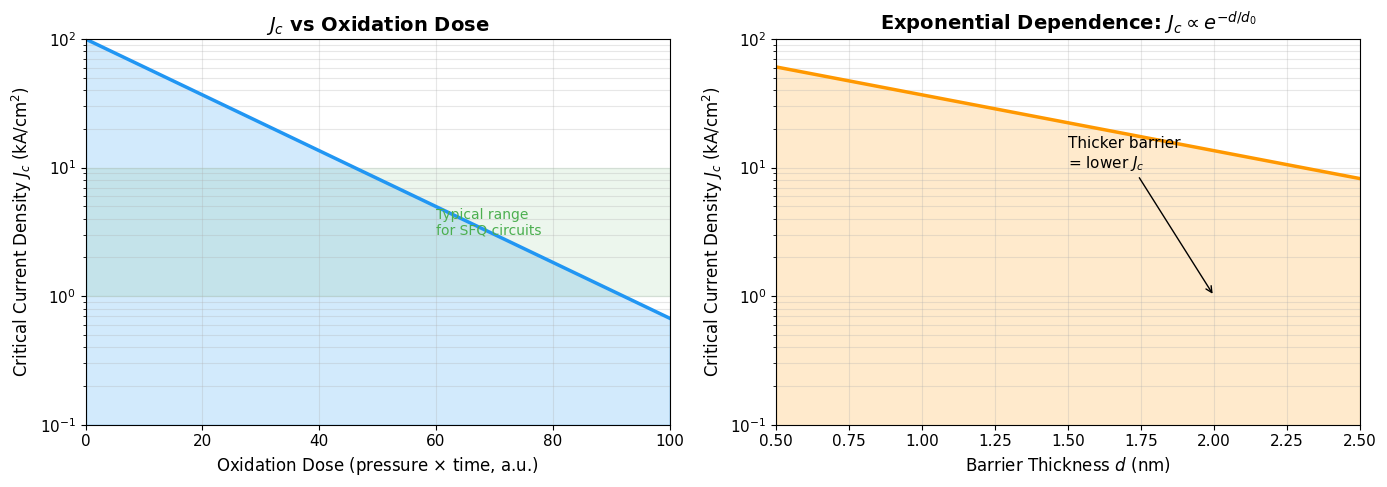

Process control is critical for reproducible junction fabrication.
Typical uniformity: +/- 5% across a wafer for mature processes.


In [16]:
# Visualize: Jc vs oxidation parameters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Jc vs oxidation dose (pressure * time)
dose = np.linspace(0.1, 100, 100)  # Arbitrary units
Jc = 100 * np.exp(-0.05 * dose)  # kA/cm^2

ax1.semilogy(dose, Jc, color=COLORS['primary'], linewidth=2.5)
ax1.fill_between(dose, 0.1, Jc, alpha=0.2, color=COLORS['primary'])

# Mark typical operating regions
ax1.axhspan(1, 10, alpha=0.1, color=COLORS['success'])
ax1.text(60, 3, 'Typical range\nfor SFQ circuits', fontsize=10, color=COLORS['success'])

ax1.set_xlabel('Oxidation Dose (pressure $\\times$ time, a.u.)', fontsize=12)
ax1.set_ylabel('Critical Current Density $J_c$ (kA/cm$^2$)', fontsize=12)
ax1.set_title('$J_c$ vs Oxidation Dose', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
ax1.set_ylim(0.1, 100)
ax1.grid(True, alpha=0.3, which='both')

# Barrier thickness vs Jc
d = np.linspace(0.5, 2.5, 100)  # nm
d0 = 0.2  # nm
Jc_barrier = 100 * np.exp(-d / d0 / 5)  # Simplified

ax2.semilogy(d, Jc_barrier, color=COLORS['secondary'], linewidth=2.5)
ax2.fill_between(d, 0.01, Jc_barrier, alpha=0.2, color=COLORS['secondary'])

ax2.set_xlabel('Barrier Thickness $d$ (nm)', fontsize=12)
ax2.set_ylabel('Critical Current Density $J_c$ (kA/cm$^2$)', fontsize=12)
ax2.set_title('Exponential Dependence: $J_c \\propto e^{-d/d_0}$', fontsize=14, fontweight='bold')
ax2.set_xlim(0.5, 2.5)
ax2.set_ylim(0.1, 100)
ax2.grid(True, alpha=0.3, which='both')

# Add annotation
ax2.annotate('Thicker barrier\n= lower $J_c$', xy=(2, 1), xytext=(1.5, 10),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)

plt.tight_layout()
plt.show()

print("Process control is critical for reproducible junction fabrication.")
print("Typical uniformity: +/- 5% across a wafer for mature processes.")

---
<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); color: white; padding: 30px; margin: 20px -10px -10px -10px; border-radius: 15px 15px 0 0;">

## Summary

### The Josephson Effect
- **DC effect**: $I = I_c \sin(\varphi)$ — supercurrent at zero voltage
- **AC effect**: $V = (\Phi_0/2\pi)(d\varphi/dt)$ — phase evolution with voltage
- **Josephson frequency**: $f = V/\Phi_0 = 483.6$ GHz/mV

### Junction Dynamics (RCSJ Model)
- Stewart-McCumber parameter: $\beta_c = 2\pi I_c R^2 C / \Phi_0$
- $\beta_c << 1$: Overdamped, non-hysteretic (used for logic)
- $\beta_c >> 1$: Underdamped, hysteretic (needs shunting)

### Key Numbers to Remember

- **I_cR_n product**: ~1.9 mV
- **Specific capacitance**: 40-100 fF/μm²
- **J_c range**: 0.1 - 100 kA/cm²
- **Gap voltage 2Δ/e**: 2.8 mV

### Junction Types
- **SIS**: Highest $I_cR_n$, standard for digital circuits
- **SNS**: Inherently overdamped, lower $I_cR_n$
- **SFS**: Enables pi-junctions for phase shifters

### Next Session
**Analog Devices** — SQUIDs and other analog superconducting circuits

</div>